# Shrihari Viswanathan
Data analysis of the kaggle data set <br>
https://www.kaggle.com/datasets/bhaweshsinha07/bengaluru-house-price-dataset

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.linear_model import LinearRegression       
from sklearn.ensemble import RandomForestRegressor      
from sklearn.tree import DecisionTreeRegressor  
from xgboost import XGBRegressor                     
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
%matplotlib inline

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


array([[<Axes: title={'center': 'bath'}>,
        <Axes: title={'center': 'balcony'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >]], dtype=object)

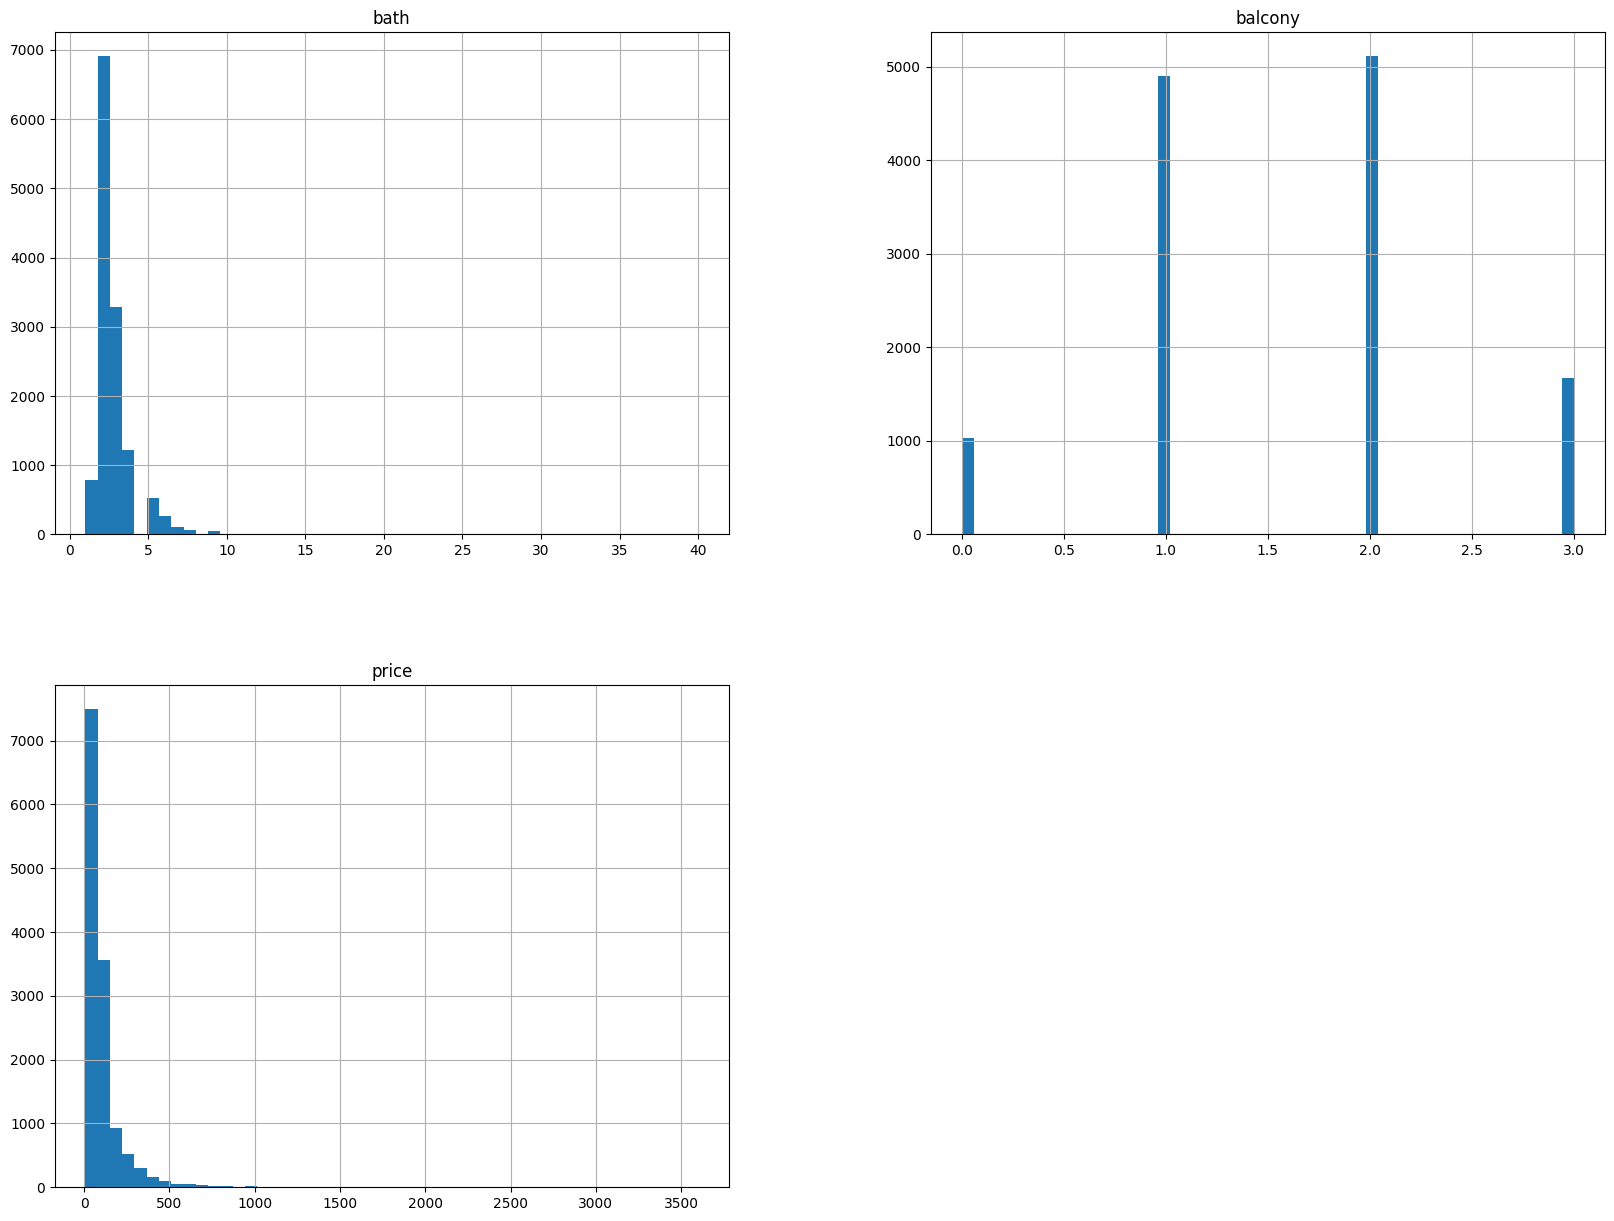

In [5]:
df.hist(bins = 50, figsize = (20, 15))


#### The null values are there in location, society, bath, balcony 

#### Updating "bath" and "balcony" to their respective means

In [6]:
df["bath"] = df["bath"].fillna(df["bath"].mean())

In [7]:
print(df["balcony"].isnull().sum())
df["balcony"] = df["balcony"].fillna(df["balcony"].mean())

609


#### Assigining the null values to the most common location and 
#### Filtering out <2 locations from "location" to others

In [8]:
df["location"].value_counts()

location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 1305, dtype: int64

In [9]:
df["location"] = df["location"].fillna("Whitefield")

counts = df["location"].value_counts()
df["location"] = df["location"].apply(lambda x : x  if counts[x] > 2 else "others")

#### Removing the society column as more than half of the data is missing

In [10]:
df.drop(["society"], axis = 1, inplace = True)

#### taking care of the values in the size columns

In [11]:
df["size"].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [12]:

pattern = [r"[1-9]\s*BHK", r"[1-9]\s*Bedroom", r"[1-9]\s*RK"]

def unwanted_text_remover(column):
    for index, val in column.items():
        if isinstance(val, str) and (re.search(pattern[0], val)):
            number = re.search(r"[1-9]", val).group()
            
            df.loc[index, "Bedroom"] = number
            df.loc[index, ["Hall", "Kitchen"]] = 1

        if isinstance(val, str) and (re.search(pattern[1], val)):
            number = re.search(r"[1-9]", val).group()
            
            df.loc[index, "Bedroom"] = number
            df.loc[index, ["Hall", "Kitchen"]] = 0

        if isinstance(val, str) and re.search(pattern[2], val):
            number = re.search(r"[1-9]", val).group()
            df.loc[index, "Bedroom"] = number
            df.loc[index, "Kitchen"] = 1
            df.loc[index, "Hall"] = 0
        
            
unwanted_text_remover(df["size"])


In [13]:
df.drop(["size"], axis = 1, inplace = True)

In [14]:
df[["Bedroom", "Hall", "Kitchen"]].isnull().sum()

Bedroom    30
Hall       30
Kitchen    30
dtype: int64

In [15]:
print(df[df["Bedroom"].isnull()][["Bedroom", "Hall", "Kitchen"]])

      Bedroom  Hall  Kitchen
579       NaN   NaN      NaN
1735      NaN   NaN      NaN
1775      NaN   NaN      NaN
1795      NaN   NaN      NaN
2264      NaN   NaN      NaN
2809      NaN   NaN      NaN
2862      NaN   NaN      NaN
3096      NaN   NaN      NaN
3523      NaN   NaN      NaN
4510      NaN   NaN      NaN
4691      NaN   NaN      NaN
5333      NaN   NaN      NaN
6423      NaN   NaN      NaN
6451      NaN   NaN      NaN
6636      NaN   NaN      NaN
6719      NaN   NaN      NaN
7680      NaN   NaN      NaN
8306      NaN   NaN      NaN
8565      NaN   NaN      NaN
8636      NaN   NaN      NaN
8703      NaN   NaN      NaN
9511      NaN   NaN      NaN
9769      NaN   NaN      NaN
10634     NaN   NaN      NaN
11019     NaN   NaN      NaN
11128     NaN   NaN      NaN
11142     NaN   NaN      NaN
11327     NaN   NaN      NaN
11569     NaN   NaN      NaN
13067     NaN   NaN      NaN


In [16]:
for col in ["Bedroom", "Hall", "Kitchen"]:
    df[col] = df[col].astype(float)                       
    df[col] = df[col].fillna(df[col].mean()).astype(int)  


In [17]:
df.isnull().sum()

area_type       0
availability    0
location        0
total_sqft      0
bath            0
balcony         0
price           0
Bedroom         0
Hall            0
Kitchen         0
dtype: int64

#### Area Type can be one hot encoderised"

In [18]:
df["area_type"].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [19]:
dummy = pd.get_dummies(df["area_type"])
df = pd.concat([df, dummy], axis =1)
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,Bedroom,Hall,Kitchen,Built-up Area,Carpet Area,Plot Area,Super built-up Area
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2,1,1,False,False,False,True
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4,0,0,False,False,True,False
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3,1,1,True,False,False,False
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3,1,1,False,False,False,True
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2,1,1,False,False,False,True


In [20]:
df.drop("area_type", axis = 1, inplace = True)

#### The availability can be grouped into their own respective months for regression

In [21]:
for index, val in df["availability"].items():
    if val[3: ] in ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]:
        df.loc[index, "availability"] = val[3 : ]

df.head()

,availability,location,total_sqft,bath,balcony,price,Bedroom,Hall,Kitchen,Built-up Area,Carpet Area,Plot Area,Super built-up Area
0,Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2,1,1,False,False,False,True
1,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4,0,0,False,False,True,False
2,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3,1,1,True,False,False,False
3,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3,1,1,False,False,False,True
4,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2,1,1,False,False,False,True


In [22]:
df["availability"].unique()

array(['Dec', 'Ready To Move', 'May', 'Feb', 'Nov', 'Oct', 'Sep', 'Mar',
       'Apr', 'Aug', 'Jun', 'Jan', 'Jul', 'Immediate Possession'],
      dtype=object)

In [23]:
dummy = pd.get_dummies(df["availability"])
df = pd.concat([df, dummy], axis = 1)
df.drop("availability", axis =1, inplace = True)


#### location is still off, there are too many locations, grouping locations based on their proximity to each other

In [24]:
df["location"].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli',
       'Lingadheeranahalli', 'Kothanur', 'Whitefield', 'Old Airport Road',
       'Rajaji Nagar', 'Marathahalli', 'others', '7th Phase JP Nagar',
       'Gottigere', 'Sarjapur', 'Mysore Road', 'Bisuvanahalli',
       'Raja Rajeshwari Nagar', 'Ramakrishnappa Layout',
       'Manayata Tech Park', 'Kengeri', 'Binny Pete', 'Thanisandra',
       'Bellandur', ' Thanisandra', 'Mangammanapalya', 'Electronic City',
       'Ramagondanahalli', 'Yelahanka', 'Hebbal', 'Kasturi Nagar',
       'Kanakpura Road', 'Electronics City Phase 1', 'Kundalahalli',
       'Chikkalasandra', 'Murugeshpalya', 'Sarjapur  Road', 'Ganga Nagar',
       'HSR Layout', 'Doddathoguru', 'KR Puram', 'Himagiri Meadows',
       'Bhoganhalli', 'Lakshminarayana Pura', 'Begur Road', 'Devanahalli',
       'Varthur', 'Bommanahalli', 'Gunjur', 'Devarachikkanahalli',
       'Hegde Nagar', 'Haralur Road', 'Hennur Road', 'Kothannur',
       'Kalena Agrahara', 'Chola

In [25]:
location_to_group = clusters = {
    "Electronic City & Vicinity": [
        "Electronic City", "Electronic City Phase II", "Electronics City Phase 1",
        "Bommasandra", "Bommasandra Industrial Area", "Singena Agrahara", "Doddathoguru",
        "Kammasandra", "Rayasandra", "Neeladri Nagar", "Stage-4 Bommanahalli", "Bommanahalli",
        "Hosa Road", "Huskur", "Chandapura", "Jigani", "Marsur", "Hulimavu"
    ],
    "Whitefield Cluster": [
        "Whitefield", "EPIP Zone", "ITPL", "Kadugodi", "Immadihalli", "Seegehalli", 
        "Pattandur Agrahara", "Hagadur", "Ramagondanahalli", "Nallurhalli", "Hoodi", "Hoodi Circle, ",
        "Basavanapura", "Sadaramangala", "Belathur", "Kannamangala", "Devasthanagalu", "Varthur", "Balagere"
    ],
    "Sarjapur & Vicinity": [
        "Sarjapur", "Sarjapura - Attibele Road", "Sarjapur  Road", "Sarjapur Road, ", "Kasavanhalli",
        "Kaikondrahalli", "Dommasandra", "Kodathi", "Ambalipura", "Gunjur", "Off Sarjapur Road, ",
        "Chikka Tirupathi"
    ],
    "JP Nagar & Surroundings": [
        "JP Nagar", "1st Phase JP Nagar", "2nd Phase JP Nagar", "3rd Phase JP Nagar", "4th Phase JP Nagar",
        "5th Phase JP Nagar", "6th Phase JP Nagar", "7th Phase JP Nagar", "8th Phase JP Nagar",
        "9th Phase JP Nagar", "NS Palya", "Puttenahalli", "Konanakunte", "Talaghattapura", "Ramanjaneyanagar",
        "Sarakki Nagar", "Subramanyapura", "Vasantha Vallabha Nagar", "Konanakunte Cross"
    ],
    "Jayanagar & Basavangudi": [
        "Jayanagar", "1st Block Jayanagar", "3rd Block Jayanagar", "4th Block Jayanagar",
        "5th Block Jayanagar", "7th Block Jayanagar", "8th Block Jayanagar", "9th Block Jayanagar",
        "4th T block Jayanagar", "Basavangudi", "Wilson Garden", "Suddaguntepalya", "Hanumanth Nagar",
        "Siddapura", "KR Road"
    ],
    "Hebbal & Thanisandra Corridor": [
        "Hebbal", "Hebbal Kempapura", "Thanisandra", " Thanisandra", "Thanisandra Main Road, ",
        "Nagavara", "Nagawara Junction", "Hegde Nagar", "Amruthahalli", "Kodigehalli", "Jakkur", "Jakkuru Layout",
        "Tirumanahalli", "Kogilu", "Attur Layout", "Rachenahalli", "Bagalur Main Road", "Sahakara Nagar"
    ],
    "Yelahanka": [
        "Yelahanka", "Yelahanka New Town", "Singanayakanahalli", "Vidyaranyapura", "Kattigenahalli",
        "Rajankunte"
    ],
    "KR Puram & East": [
        "KR Puram", "Lakshminarayana Pura", "Battarahalli", "Dooravani Nagar", "Ramamurthy Nagar",
        "Ramamurthy Nagar Extension", "TC Palaya", "T.C PALYA", "Medahalli", "Budigere", "Old Madras Road"
    ],
    "HSR Layout & Bommanahalli": [
        "HSR Layout", "Sector 1 HSR Layout", "Sector 2 HSR Layout", "Sector 6 HSR Layout", "Sector 7 HSR Layout",
        "Mangammanapalya", "Kudlu Gate", "Kudlu", "Basapura", "Singasandra", "Parappana Agrahara", "Iblur Village",
        "Green Glen Layout", "Somasundara Palya", "Stage-4 Bommanahalli"
    ],
    "Indiranagar & Domlur": [
        "Indira Nagar", "HAL 2nd Stage", "1st Stage Indira Nagar", "Indiranagar Club", "Domlur", "Domlur Layout",
        "New Thippasandra", "Kodihalli", "Rustam Bagh Layout", "CMH Road"
    ],
    "Marathahalli - Brookefield - ORR": [
        "Marathahalli", "Brookefield", "Dodda Nekkundi", "Dodda Nekkundi Extension", "AECS Layout", "Kundalahalli",
        "Kundalahalli Colony", "Munnekollal", "Doddanekkundi", "Thubarahalli", "Pattandur Agrahara", "Garudachar Palya"
    ],
    "Koramangala & Surroundings": [
        "Koramangala", "1st Block Koramangala", "4th Block Koramangala", "6th block Koramangala",
        "8th block Koramangala", "Ejipura", "St Johns Road", "Jakkasandra Extension", "Madiwala", "Roopena Agrahara"
    ],
    "Bannerghatta Road / Arekere / Gottigere": [
        "Bannerghatta Road", "Arekere", "Gottigere", "Devarachikkanahalli", " Devarachikkanahalli", 
        "Vijaya Bank Layout", "Bilekahalli", "Hulimavu", "Yelenahalli", "Begur", "Vajralli", "Basapura"
    ],
    "Rajajinagar & Malleshwaram": [
        "Rajaji Nagar", "Malleshwaram", "Basaveshwara Nagar", "Yeshwanthpur", "Peenya", "Mahalakshmi Layout",
        "Mathikere", "Jalahalli West", "Jalahalli", "Nandini Layout", "Srirampura"
    ],
    "Kengeri & Rajarajeshwari Nagar": [
        "Kengeri", "Kengeri Satellite Town", "Raja Rajeshwari Nagar", "Ramakrishnappa Layout", 
        "Rajarajeshwari nagar", "Bisuvanahalli", "Kenchenahalli", "Mylasandra", "Byatarayanapura"
    ],
    "Sarjapur Extension & South-East": [
        "Dommasandra", "Ambalipura", "Kaikondrahalli", "Kodathi", "Gunjur", "Hadosiddapura",
        "Choodasandra", "Rayasandra", "Somasundara Palya"
    ],
    "West & North-West Bangalore": [
        "Nagarbhavi", "Chandra Layout", "Vishveshwarya Layout", "Vijayanagar", "Ngef Layout",
        "Magadi Road", "Dasanapura", "Gollarapalya Hosahalli", "T Dasarahalli", "Herohalli", "Laggere",
        "Sunkadakatte", "Mallathahalli", "Byagadadhenahalli"
    ],
    "Other South Bangalore": [
        "Chikkalasandra", "Padmanabhanagar", "Uttarahalli", "Lingadheeranahalli", "Kalena Agrahara",
        "Vajarahalli", "Thurahalli", "Naganathapura", "Anjanapura", "Kaggalipura", "Kanakapura Road"
    ],
    "East Bangalore Corridors": [
        "Kaggadasapura", "Mahadevpura", "Hoodi", "Hoodi Circle, ", "Garudachar Palya", "Panathur",
        "Nagondanahalli", "Bhoganhalli", "Balagere", "Bellandur", "Bellatur", "Varthur Road"
    ],
    "Northeast Cluster": [
        "Hennur Road", "Hennur", "Horamavu", "Horamavu Agara", "Kalyan nagar", "OMBR Layout", 
        "Kasturi Nagar", "Kothanur", "Kothannur", "HRBR Layout", "Babusapalaya", "HBR Layout", 
        "Kammanahalli", "Banaswadi", "Chikka Banaswadi"
    ],
    "Central Bangalore": [
        "Richmond Town", "Langford Town", "Shanthala Nagar", "Victoria Layout", "Cunningham Road",
        "Lavelle Road", "Mahatma Gandhi Road (MG Road)", "Ulsoor", "Cambridge Layout"
    ],
    "Basavangudi & Surroundings": [
        "Basavangudi", "Wilson Garden", "KR Road", "Hanumanth Nagar", "Gandhi Bazaar", 
        "Siddapura", "V V Puram", "Lalbagh"
    ],
    "Outer and Peripheral Areas": [
        "Old Airport Road", "Mysore Road", "Mysore Highway", "Devanahalli", "Devanahalli Int. Airport",
        "Anekal", "Budigere", "Bisuvanahalli", "Nelamangala", "Hoskote", "Chikka Tirupathi", 
        "Attibele", "Marsur", "Kanakapura", "Channasandra Layout", "Kadubeesanahalli"
    ],
    # Remnant/miscellaneous or ambiguous areas go in:
    "Others": [
        "others", "Manayata Tech Park", "Binny Pete", "Ganga Nagar", "Himagiri Meadows", "Lakshminarayana Pura",
        "Shampura", "LB Shastri Nagar", "MS Pallya", "Langford Town", "Green View Layout",
        "Shantiniketan Layout", "Dinnur", "Kannamangala", "Kalena Agrahara", "Cholanayakanahalli",
        "Kaval Byrasandra", "ISRO Layout", "Dasanapura", "Sanjay nagar", "Mylasandra", "Anandapura",
        "Doddadommasandra", "Ashwath Nagar", "Ashirvad Colony", "MCECHS  layout", "Coffee Board Layout",
        "Motappa Layout", "Akshaya Vana","Basavanna Nagar", "RMV Extension", "Tejaswini Nagar", 
        "Kothnur Narayanapura", "Kumaraswami Layout", "Anekal","Green Glen Layout","Various small layouts etc."
    ]
}


def get_location_group(location):
    location = location.strip()  
    for group, locations in location_to_group.items():
        if location in [loc.strip() for loc in locations]:
            return group
    return "Others"  # Fallback group

df["location"] = df["location"].apply(get_location_group)

print(df["location"].unique())
print(df["location"].isnull().sum())

['Electronic City & Vicinity' 'Sarjapur & Vicinity'
 'Other South Bangalore' 'Northeast Cluster' 'Whitefield Cluster'
 'Outer and Peripheral Areas' 'Rajajinagar & Malleshwaram'
 'Marathahalli - Brookefield - ORR' 'Others' 'JP Nagar & Surroundings'
 'Bannerghatta Road / Arekere / Gottigere'
 'Kengeri & Rajarajeshwari Nagar' 'Hebbal & Thanisandra Corridor'
 'East Bangalore Corridors' 'HSR Layout & Bommanahalli' 'Yelahanka'
 'KR Puram & East' 'West & North-West Bangalore' 'Indiranagar & Domlur'
 'Koramangala & Surroundings' 'Central Bangalore'
 'Jayanagar & Basavangudi' 'Sarjapur Extension & South-East']
0


In [26]:
dummy = pd.get_dummies(df["location"])
df = pd.concat([df, dummy], axis = 1)
df.drop("location", axis = 1, inplace = True)


#### CONVERTING ALL OF THE DATA TYPES INTO INT FOR SIMILARITY

In [27]:
df["bath"] = df["bath"].astype(int)

In [28]:
df["balcony"] = df["balcony"].astype(int)

#### CAPPING THE BATH TO 5

In [29]:
df["bath"].value_counts()

bath
2     6981
3     3286
4     1226
1      788
5      524
6      273
7      102
8       64
9       43
10      13
12       7
11       3
13       3
16       2
27       1
14       1
40       1
15       1
18       1
Name: count, dtype: int64

In [30]:
df["bath"] = df["bath"].apply(lambda x: 5 if x > 5 else int(x))

In [31]:
df.describe()

,bath,balcony,price,Bedroom,Hall,Kitchen
count,13320.000000,13320.000000,13320.000000,13320.000000,13320.000000,13320.000000
mean,2.605631,1.557658,112.565627,2.780105,0.808108,0.809084
std,1.004658,0.807639,148.971674,1.168284,0.393803,0.393038
min,1.000000,0.000000,8.000000,1.000000,0.000000,0.000000
25%,2.000000,1.000000,50.000000,2.000000,1.000000,1.000000
50%,2.000000,2.000000,72.000000,3.000000,1.000000,1.000000
75%,3.000000,2.000000,120.000000,3.000000,1.000000,1.000000
max,5.000000,3.000000,3600.000000,9.000000,1.000000,1.000000


#### there is a total_sqft inconsistency

In [32]:
def split_mean(column):
    column_updated = column.copy()  # avoid modifying original directly
    for index, val in column.items():
        # Only process strings with "-"
        if isinstance(val, str) and '-' in val:
            parts = val.split('-')
            val1, val2 = float(parts[0].strip()), float(parts[1].strip())
            mean = (val1 + val2) / 2
            column_updated.at[index] = mean
        else:
            # Leave numeric values as-is
            try:
                column_updated.at[index] = float(val)
            except:
                column_updated.drop(index, axis = 0, inplace = True)
    return column_updated

In [33]:
df["total_sqft"] = split_mean(df["total_sqft"])
df["total_sqft"] = df["total_sqft"].astype(float)

In [34]:
df = df.dropna(subset = ["total_sqft"])

In [35]:
df["sqft_per_bedroom"] = df["total_sqft"] / df["Bedroom"]

df = df[df["sqft_per_bedroom"] >= 300]

df = df.drop(columns=["sqft_per_bedroom"])

In [36]:
df.columns
df["price"] = np.log1p(df["price"])

## DATA PREP OVER
#### EDA 

In [37]:
corr = df.corr()
corr["price"].sort_values(ascending=False)

price                                      1.000000
bath                                       0.721975
Bedroom                                    0.655195
total_sqft                                 0.581916
Plot  Area                                 0.344026
balcony                                    0.150297
Rajajinagar & Malleshwaram                 0.138118
Central Bangalore                          0.125209
Indiranagar & Domlur                       0.112415
Jayanagar & Basavangudi                    0.094847
Koramangala & Surroundings                 0.086527
Ready To Move                              0.080647
Others                                     0.053139
Hebbal & Thanisandra Corridor              0.052582
Marathahalli - Brookefield - ORR           0.021725
Mar                                        0.015543
Sarjapur & Vicinity                        0.014344
Feb                                        0.014299
Whitefield Cluster                         0.013550
JP Nagar & S

<Axes: >

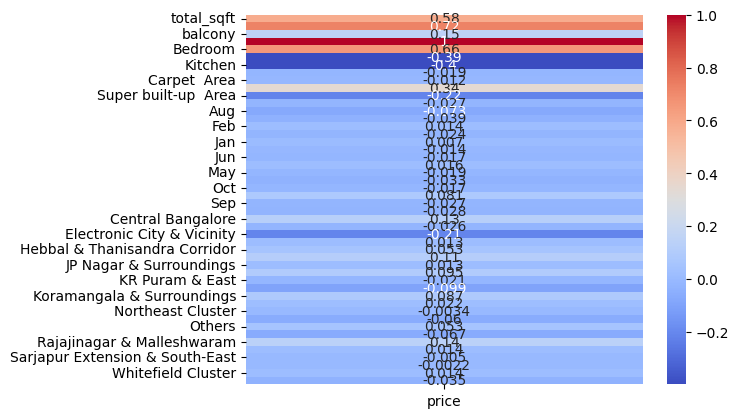

In [38]:
sns.heatmap(df.corr()[["price"]], annot=True, cmap="coolwarm")

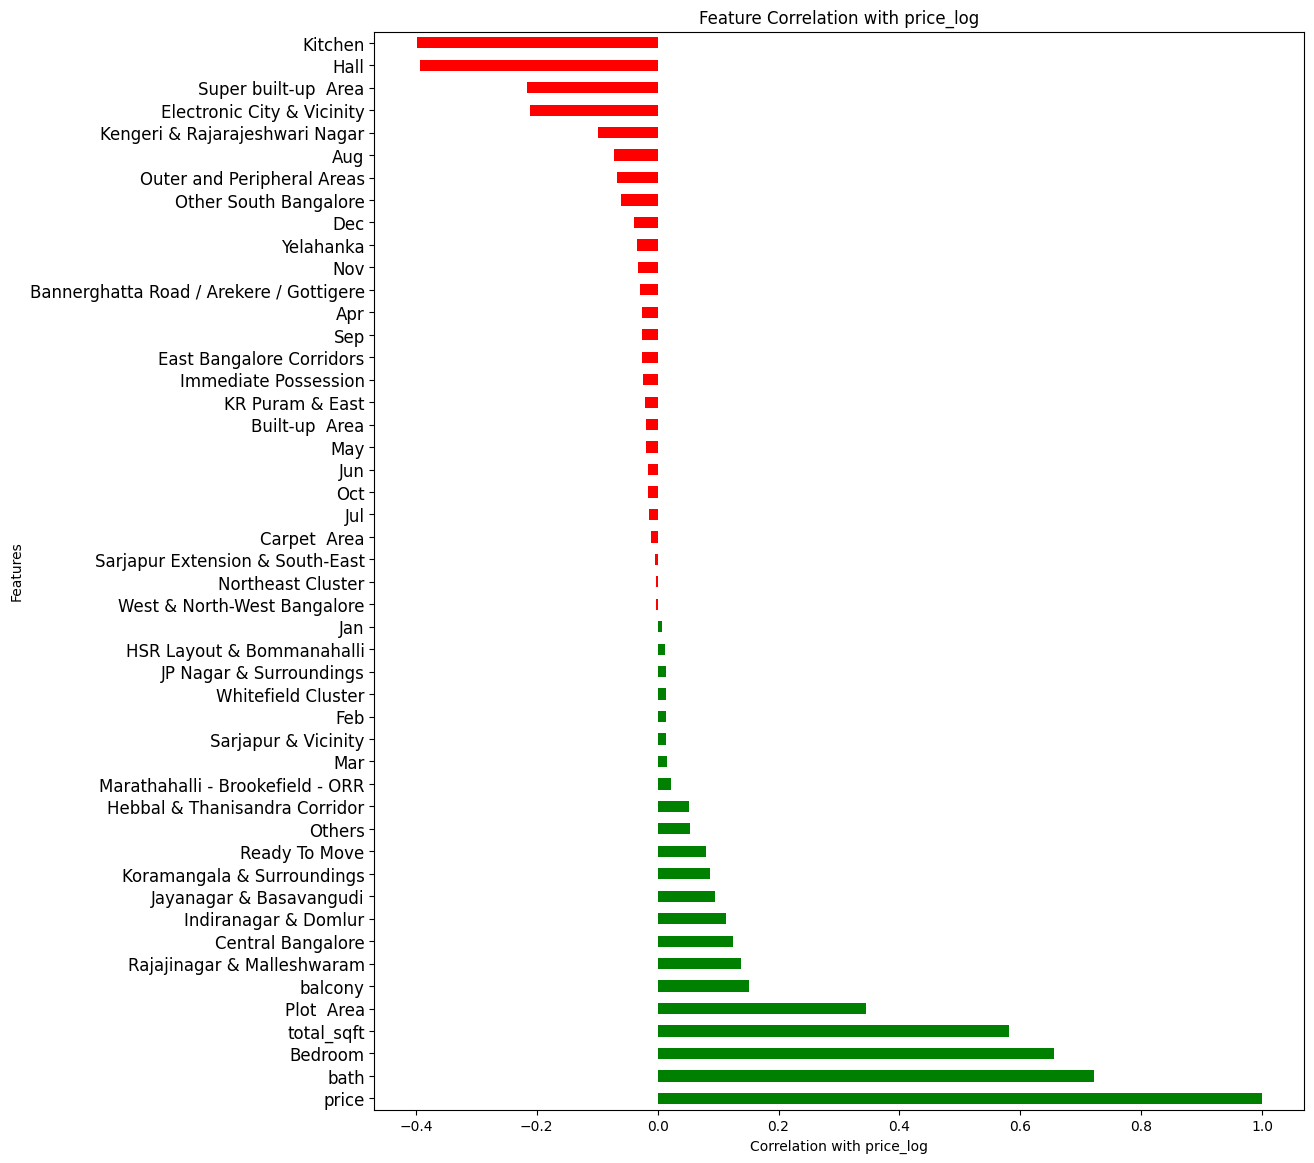

In [39]:
corr = df.corr()
price_log_corr = corr["price"].sort_values(ascending = False)
colors = ['green' if val > 0 else 'red' for val in price_log_corr]


# Create the figure with desired size BEFORE plotting
plt.figure(figsize=(12, 14))

# Plot horizontal bar chart
price_log_corr.plot(kind="barh", color=colors)

# Set labels and appearance AFTER plotting
plt.xlabel("Correlation with price_log")
plt.ylabel("Features")
plt.yticks(fontsize=12)   # Adjust fontsize for readability
plt.yticks(rotation=0)   # Horizontal labels for y-axis look better

plt.title("Feature Correlation with price_log")

plt.show()

<Axes: xlabel='total_sqft', ylabel='price'>

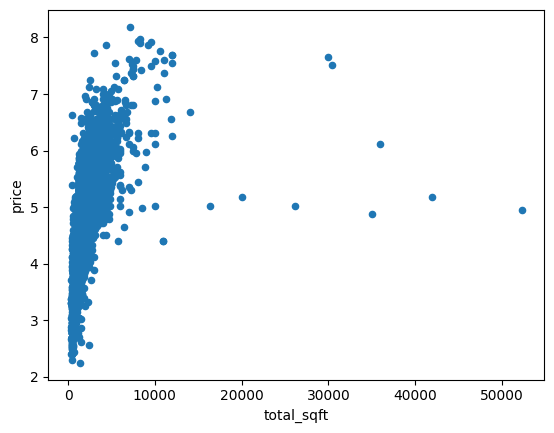

In [40]:
df.plot(kind = "scatter", x = "total_sqft", y= "price")

<Axes: >

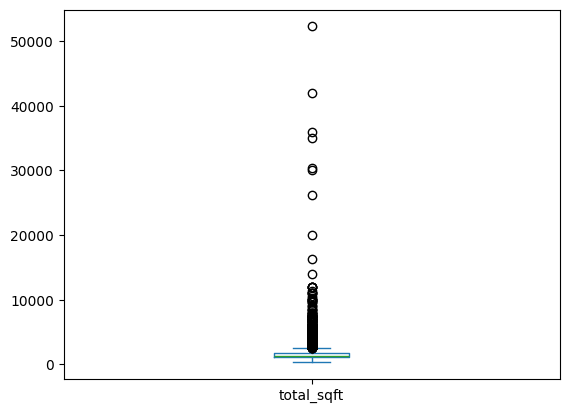

In [41]:
df["total_sqft"].plot(kind = "box")

#### MODELLING

In [42]:
x_data = df.drop("price", axis=1)
y_data = df["price"]

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.3, random_state = 0)

In [44]:
z = LinearRegression()
z.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
y_predicted = z.predict(x_test)
print(f"equation Y = {z.coef_}*X + {z.intercept_}")

equation Y = [ 1.28550344e-04  3.14390685e-01  1.69789077e-02  9.41159387e-02
  3.64187531e-01 -5.06566352e-01 -7.87171113e-02 -5.22662454e-02
  1.62709245e-01 -3.17258885e-02  3.14737969e-02 -1.12220375e-01
  6.22021625e-03  9.09423116e-02 -1.57130948e-02  1.14863998e-01
  1.42446787e-02 -3.14497475e-02  1.58704014e-01  9.39042840e-04
 -1.27969803e-01 -8.35640469e-02  2.46443837e-02 -7.11153758e-02
 -1.84663238e-01  7.37625060e-01 -1.04674008e-01 -3.63157649e-01
 -3.25577705e-02  1.57339838e-02  5.16301648e-01 -2.53024319e-03
  5.36315984e-01 -1.78965502e-01 -3.16353573e-01  3.97617112e-01
 -4.27199716e-02 -1.02965922e-01 -2.03477483e-01 -8.23121584e-02
 -3.54978431e-01  4.00406512e-01 -1.08540768e-01 -1.84217137e-01
 -6.53500005e-02 -8.52903394e-02 -1.91246104e-01]*X + 3.327860315862246


In [46]:
z.score(x_test, y_test)

0.6747972540273022

In [47]:
mse = mean_squared_error(y_test, y_predicted)
mae = mean_absolute_error(y_test, y_predicted)
print(f"mae is {mae}\nmse is {mse}")

mae is 0.2984970094351328
mse is 0.16254232359351314


In [48]:
metrics = pd.DataFrame({
    'linear': {
        'mae': 0.28021235885722107,
        'mse': 0.134471296817324,
        'r2': 0.7285537598905569
    }
})

print(metrics)

       linear
mae  0.280212
mse  0.134471
r2   0.728554


C:\Users\shrih\AppData\Local\Temp\ipykernel_2180\1967961399.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist = False, color = "r", label = "Actual Value")
C:\Users\shrih\AppData\Local\Temp\ipykernel_2180\1967961399.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn

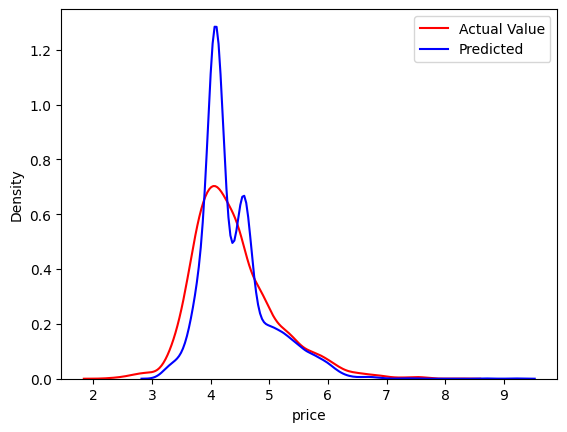

In [49]:
ax1 = sns.distplot(y_test, hist = False, color = "r", label = "Actual Value")
sns.distplot(y_predicted, hist = False, color = "b", label = "Predicted", ax = ax1)
plt.legend()

In [50]:
print("something")

poly = PolynomialFeatures(degree=2)
print(f"Running degree2")
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
    
model = LinearRegression()
model.fit(x_train_poly, y_train)

y_pred = model.predict(x_test_poly)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = model.score(x_test_poly, y_test)

print(f"Degree 2 -> mae: {mae}, mse: {mse}, r2: {r2}")

metrics.loc[["mae", "mse", "r2"], "degree2"] = [mae, mse, r2]




something
Running degree2
Degree 2 -> mae: 0.25475037269149753, mse: 0.136015906265097, r2: 0.7278693620500213


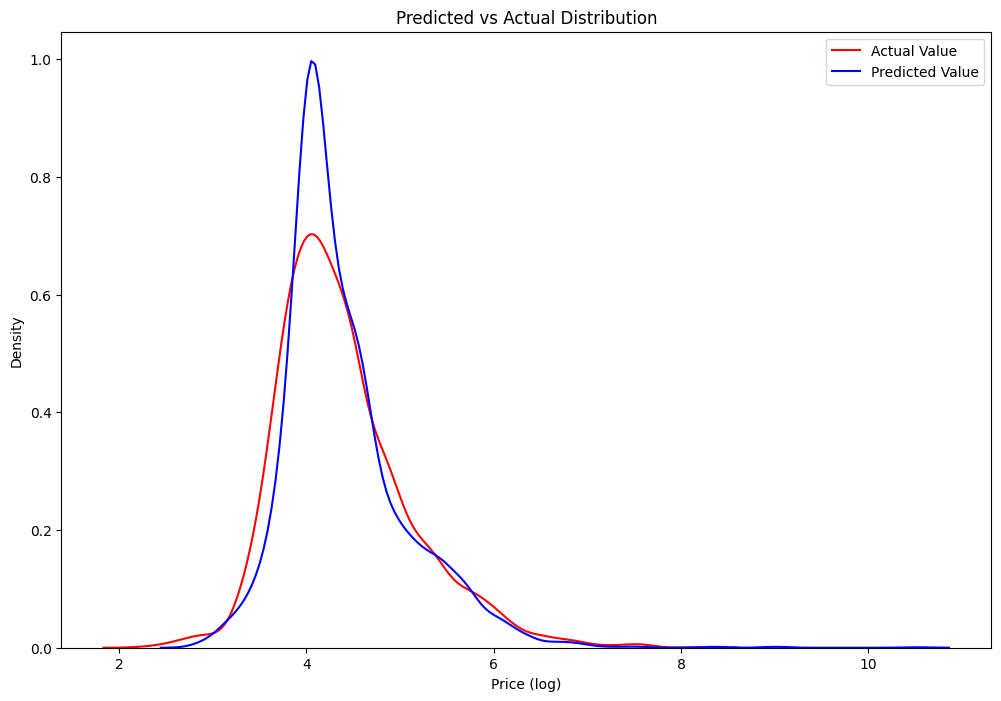

In [51]:
plt.figure(figsize=(12,8))
sns.kdeplot(y_test, color="r", label="Actual Value")
sns.kdeplot(y_pred, color="b", label="Predicted Value")
plt.xlabel("Price (log)")
plt.ylabel("Density")
plt.title("Predicted vs Actual Distribution")
plt.legend()
plt.show()

In [52]:
print("hello")


hello


In [53]:
RidgeModel = Ridge(alpha = 0.1)
RidgeModel.fit(x_train, y_train)
y_predicted = RidgeModel.predict(x_test)

In [54]:
RidgeModel.score(x_test, y_test)

0.6748302236807104

In [55]:
r2 = r2_score(y_test, y_predicted)
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)

In [56]:
metrics.loc[["mae", "mse", "r2"], "Ridge(0.1)"] = [mae, mse, r2]

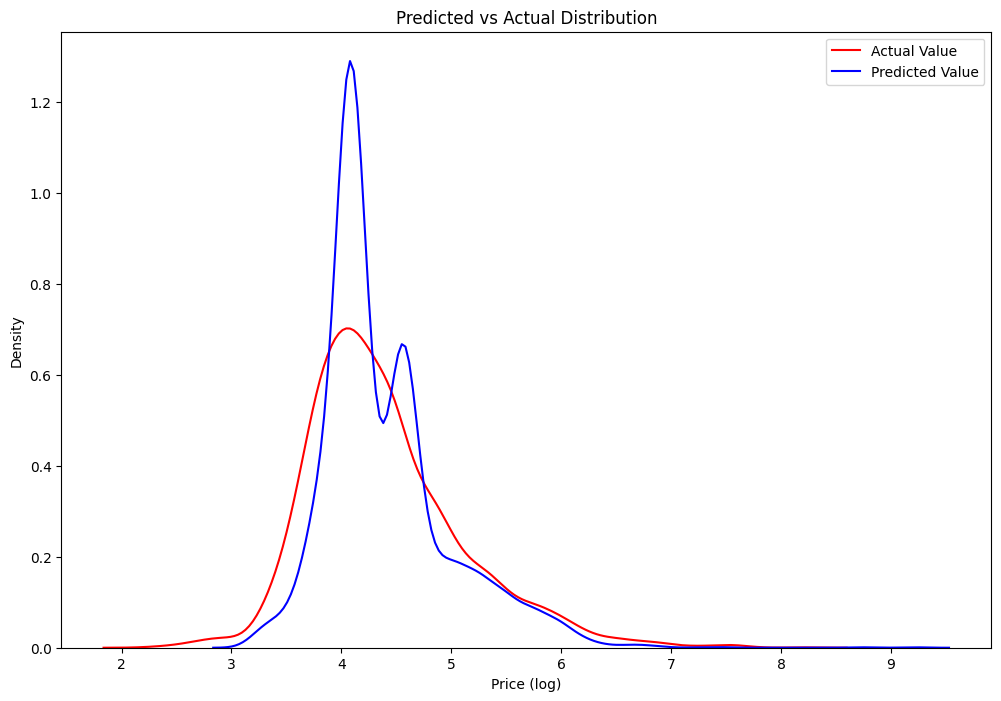

In [57]:
plt.figure(figsize=(12,8))
sns.kdeplot(y_test, color="r", label="Actual Value")
sns.kdeplot(y_predicted, color="b", label="Predicted Value")
plt.xlabel("Price (log)")
plt.ylabel("Density")
plt.title("Predicted vs Actual Distribution")
plt.legend()
plt.show()

In [58]:
parameters = [{"alpha" : [0.001, 0.01, 0.1, 1, 10, 25, 50, 75, 100, 250, 500, 750, 1000]}]
RidgeModel = Ridge(max_iter = 1000)
Grid1 = GridSearchCV(estimator = RidgeModel, param_grid = parameters, cv = 5, scoring = "r2", verbose = 2)
Grid1.fit(x_train, y_train)

Fitting 5 folds for each of 13 candidates, totalling 65 fits
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END .......................................

,estimator,Ridge(max_iter=1000)
,param_grid,"[{'alpha': [0.001, 0.01, ...]}]"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [59]:
print(Grid1.best_estimator_)
print(Grid1.best_params_)
r2 = Grid1.score(x_test, y_test)  
print(r2)

Ridge(alpha=1, max_iter=1000)
{'alpha': 1}
0.6750252368552159


In [60]:
y_pred = Grid1.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
metrics.loc[["mae", "mse", "r2"], "Ridge(1)"] = [mae, mse, r2]

MAE: 0.29838832903698836
MSE: 0.16242837357603201


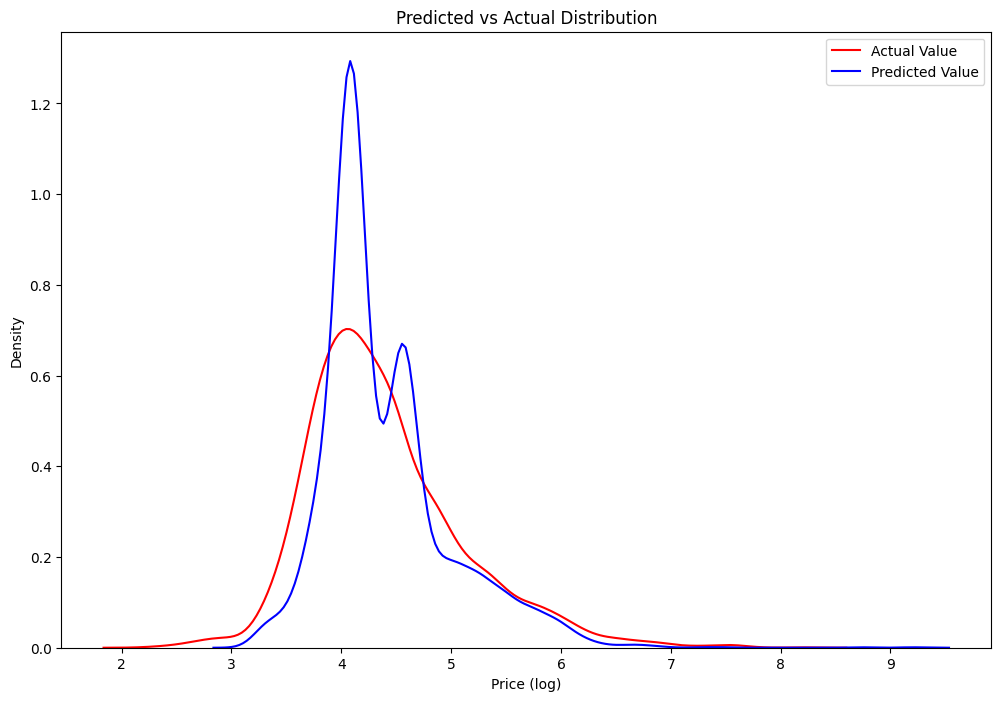

In [61]:
plt.figure(figsize=(12,8))
sns.kdeplot(y_test, color="r", label="Actual Value")
sns.kdeplot(y_pred, color="b", label="Predicted Value")
plt.xlabel("Price (log)")
plt.ylabel("Density")
plt.title("Predicted vs Actual Distribution")
plt.legend()
plt.show()

Fitting 5 folds for each of 13 candidates, totalling 65 fits
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END .......................................

<Axes: xlabel='price', ylabel='Density'>

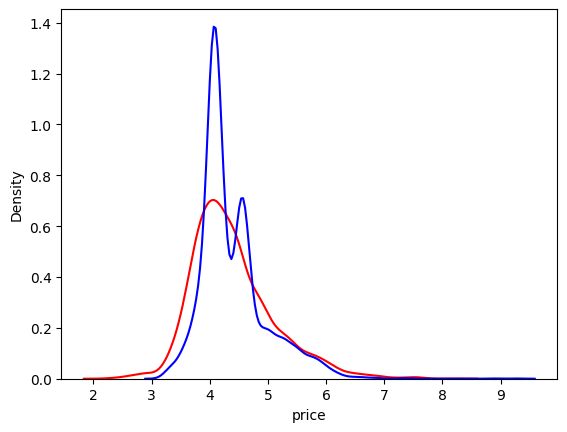

In [62]:
lasso = Lasso(max_iter = 1000)
Grid2 = GridSearchCV(estimator = lasso, param_grid = parameters, scoring = "r2", verbose = 2)
Grid2.fit(x_train, y_train)
y_predicted = Grid2.predict(x_test)

print(Grid2.best_estimator_)
alpha = Grid2.best_params_["alpha"]
r2 = Grid2.score(x_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2; {r2}")
metrics.loc[["mae", "mse", "r2"], f"Lasso{alpha}"] = [mae, mse, r2]
sns.kdeplot(y_test, color = "r", label = "Actual Value")
sns.kdeplot(y_predicted, color = "b", label = "Predicted Value")


In [63]:
#metrics.rename(columns={"Lasso(alpha)": "Lasso(0.01)"}, inplace=True)
parameters = {
    "max_depth": [3, 5, 6,7, 8, 9, 10, 15],
    "min_samples_split": [2, 5, 8, 9, 10, 11, 12, 15],
    "min_samples_leaf": [1, 2, 5]
}

# Initialize the Decision Tree Regressor
dtree = DecisionTreeRegressor(random_state=42)

Grid3 = GridSearchCV(estimator=dtree, param_grid=parameters,
                     scoring="r2", cv=6, verbose=2)

Grid3.fit(x_train, y_train)

# Predict on test data
y_pred_tree = Grid3.predict(x_test)

print("Best Decision Tree:", Grid3.best_estimator_)
best_params_tree = Grid3.best_params_

r2 = Grid3.score(x_test, y_test)
mae = mean_absolute_error(y_test, y_pred_tree)
mse = mean_squared_error(y_test, y_pred_tree)



Fitting 6 folds for each of 192 candidates, totalling 1152 fits
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_

MAE: 0.2532539356529356
MSE: 0.12249935360055325
R²: 0.7549122881348409
DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=15,
                      random_state=42)
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 15}


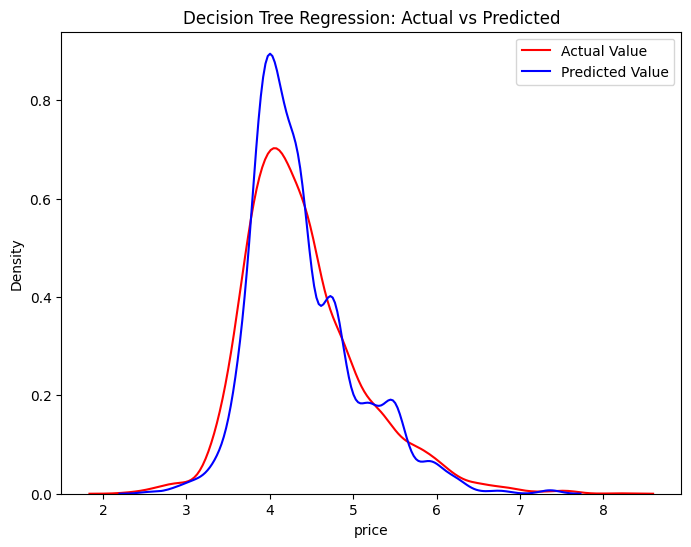

In [64]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")

print(Grid3.best_estimator_)
print(Grid3.best_params_)
# Store metrics in your metrics DataFrame
metrics.loc[["mae", "mse", "r2"], f"DecisionTreeRegressor{best_params_tree['max_depth']}"] = [mae, mse, r2]

# Plot predicted vs actual
plt.figure(figsize=(8,6))
sns.kdeplot(y_test, color="r", label="Actual Value")
sns.kdeplot(y_pred_tree, color="b", label="Predicted Value")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [65]:
parameters_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0]
}

# Initialize the XGBoost Regressor
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

# GridSearchCV
Grid4 = GridSearchCV(estimator=xgb, param_grid=parameters_xgb,
                     scoring="r2", cv=5, verbose=2)

# Fit on training data
Grid4.fit(x_train, y_train)  # ensure y is 1D

# Predict on test data
y_pred_xgb = Grid4.predict(x_test)

# Best estimator and parameters
print("Best XGBoost model:", Grid4.best_estimator_)
best_params_xgb = Grid4.best_params_
print(best_params_xgb)
print(Grid4.best_estimator_)

# Metrics
r2 = Grid4.score(x_test, y_test)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)



Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   2.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.3

MAE: 0.22848523666904708
MSE: 0.09805145900966927
R²: 0.8038258404849922


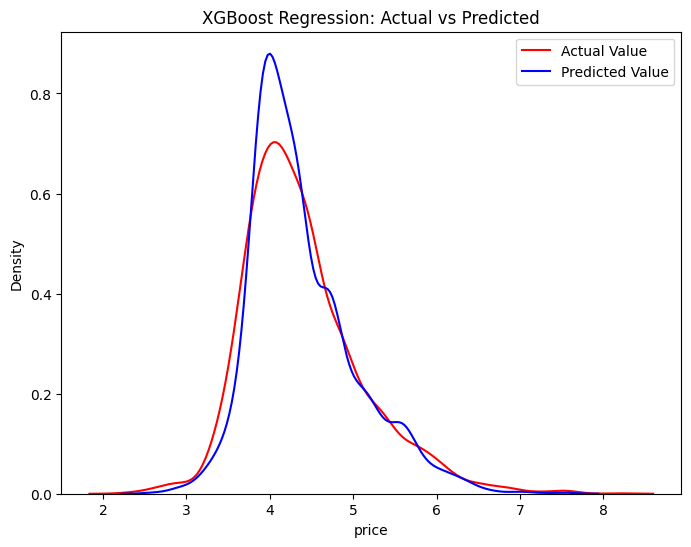

In [66]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")

# Store metrics in your metrics DataFrame
metrics.loc[["mae", "mse", "r2"], f"XGBoost_{best_params_xgb['n_estimators']}"] = [mae, mse, r2]

# Plot predicted vs actual
plt.figure(figsize=(8,6))
sns.kdeplot(y_test, color="r", label="Actual Value")
sns.kdeplot(y_pred_xgb, color="b", label="Predicted Value")
plt.title("XGBoost Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [67]:
metrics

,linear,degree2,Ridge(0.1),Ridge(1),Lasso0.001,DecisionTreeRegressor10,XGBoost_100
mae,0.280212,0.254750,0.298482,0.298388,0.298388,0.253254,0.228485
mse,0.134471,0.136016,0.162526,0.162428,0.162428,0.122499,0.098051
r2,0.728554,0.727869,0.674830,0.675025,0.673785,0.754912,0.803826


<Axes: >

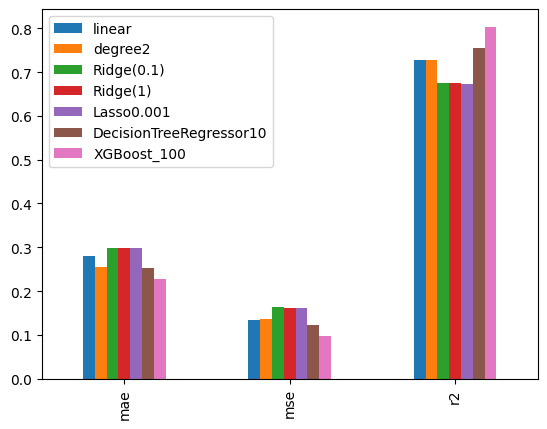

In [68]:
metrics.plot(kind = "bar")

In [74]:
import joblib
joblib.dump(Grid4, "bangalore_price_model.pkl")


['bangalore_price_model.pkl']

In [71]:
df.columns

Index(['total_sqft', 'bath', 'balcony', 'price', 'Bedroom', 'Hall', 'Kitchen',
       'Built-up  Area', 'Carpet  Area', 'Plot  Area', 'Super built-up  Area',
       'Apr', 'Aug', 'Dec', 'Feb', 'Immediate Possession', 'Jan', 'Jul', 'Jun',
       'Mar', 'May', 'Nov', 'Oct', 'Ready To Move', 'Sep',
       'Bannerghatta Road / Arekere / Gottigere', 'Central Bangalore',
       'East Bangalore Corridors', 'Electronic City & Vicinity',
       'HSR Layout & Bommanahalli', 'Hebbal & Thanisandra Corridor',
       'Indiranagar & Domlur', 'JP Nagar & Surroundings',
       'Jayanagar & Basavangudi', 'KR Puram & East',
       'Kengeri & Rajarajeshwari Nagar', 'Koramangala & Surroundings',
       'Marathahalli - Brookefield - ORR', 'Northeast Cluster',
       'Other South Bangalore', 'Others', 'Outer and Peripheral Areas',
       'Rajajinagar & Malleshwaram', 'Sarjapur & Vicinity',
       'Sarjapur Extension & South-East', 'West & North-West Bangalore',
       'Whitefield Cluster', 'Yelahanka'],
    

In [72]:
columns_list = x_train.columns.tolist()
joblib.dump(columns_list, "model_columns.pkl")

['model_columns.pkl']